Importing all necessary libraries

In [271]:
import yfinance as yf
import matplotlib.pyplot as plt
import pandas as pd
import quantstats as qs
import numpy as np


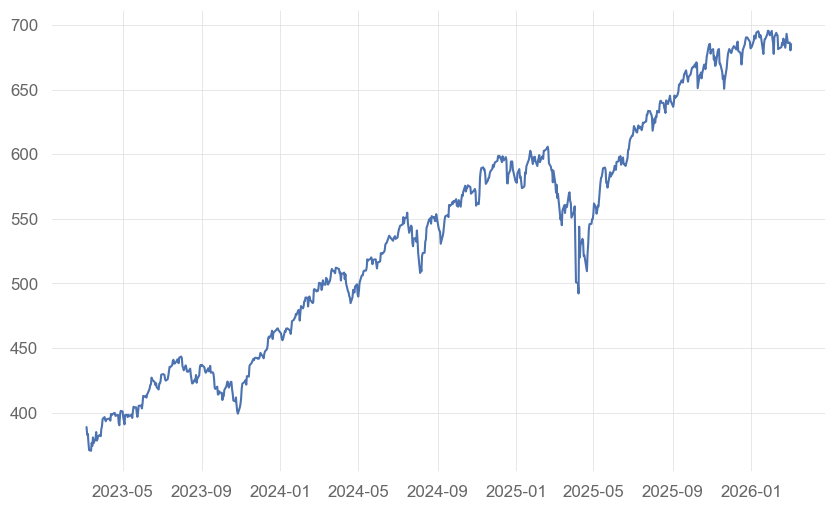

In [272]:
spy = yf.Ticker("SPY")
spy_data = spy.history(period="3y", auto_adjust = True)
spy_closes = spy_data['Close']

plt.plot(spy_closes)
plt.show()

### Plot Moving Averages


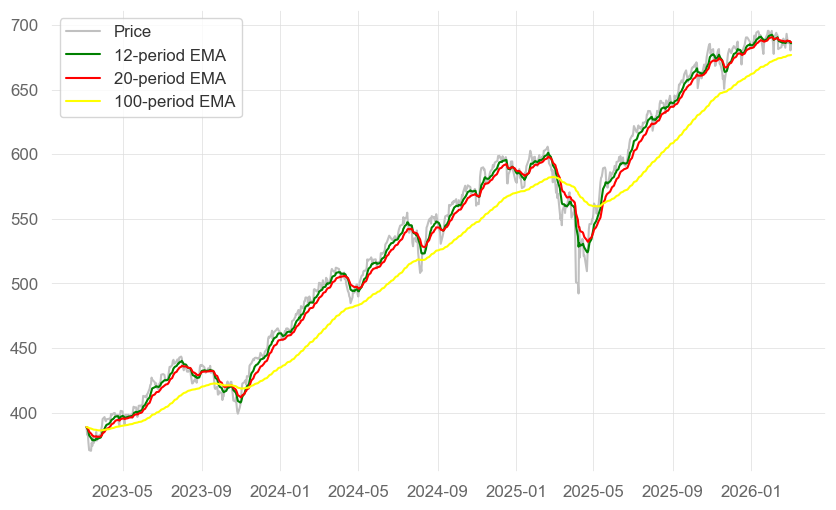

In [273]:
ema12 = spy_closes.ewm(span=10, adjust=False).mean()
ema26 = spy_closes.ewm(span=20, adjust=False).mean()
ema50 = spy_closes.ewm(span=100, adjust=False).mean()
plt.plot(spy_closes, label='Price', color='silver')
plt.plot(ema12, label='12-period EMA', color='green')
plt.plot(ema26, label='20-period EMA', color='red')
plt.plot(ema50, label ='100-period EMA', color='yellow')

plt.legend()
plt.show()

 Since SPY is known to be upwards-trending, we cant use the same moving averages for both long and short signals. Short signals have to be significant enough to become a signal. Therefore, long signals are 12 ema - 26 ema and short signals are 12 ema - 50 ema

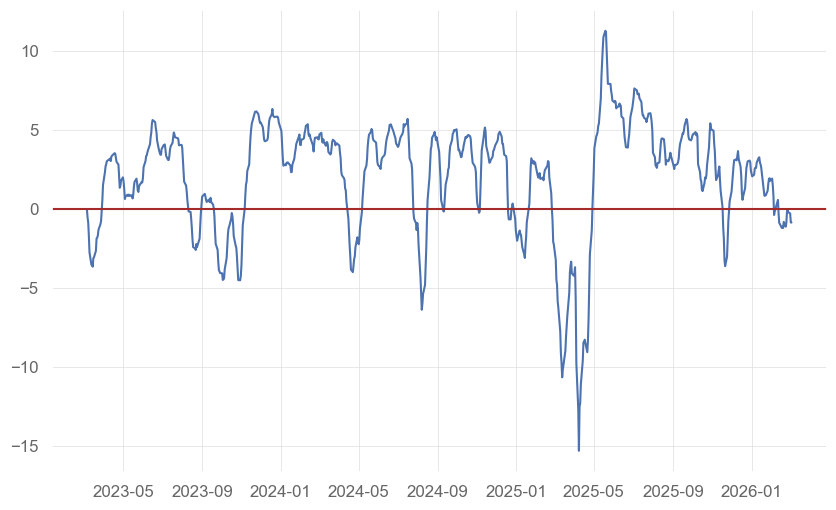

In [274]:
long_macd_line = ema12 - ema26
short_macd_line = ema12 - ema50
plt.plot(long_macd_line)
plt.axhline(0, color = "brown")
plt.show()

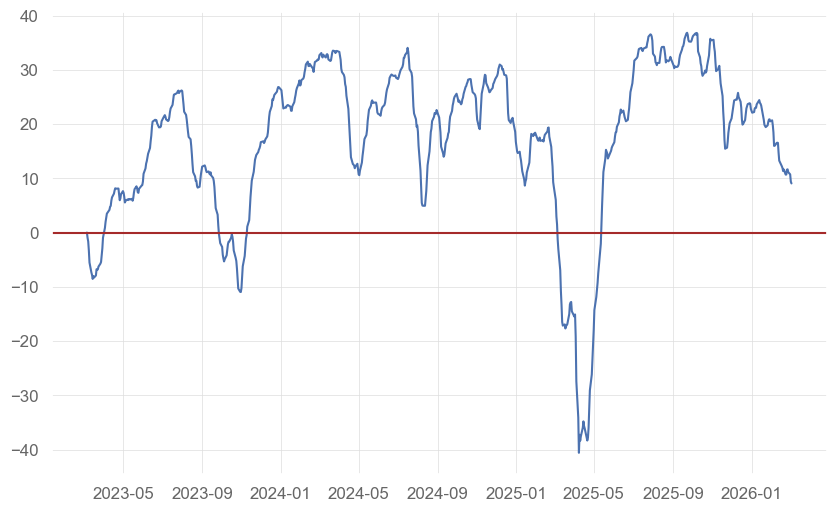

In [275]:
plt.plot(short_macd_line)
plt.axhline(0, color = "brown")
plt.show()

Generating trade signals

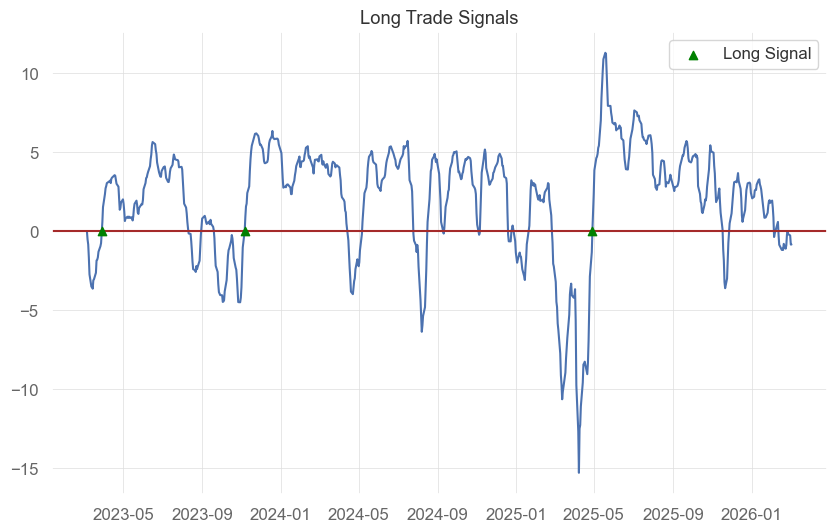

[Timestamp('2023-03-30 00:00:00-0400', tz='America/New_York'), Timestamp('2023-11-06 00:00:00-0500', tz='America/New_York'), Timestamp('2025-04-29 00:00:00-0400', tz='America/New_York')]
[Timestamp('2023-09-27 00:00:00-0400', tz='America/New_York'), Timestamp('2025-03-06 00:00:00-0500', tz='America/New_York')]


In [276]:
long_signals = []
short_signals = []
short_exit_signals = []
state = 0 #1 = Long, 0 = Neutral, -1 = Short

for i in range(1, len(long_macd_line)):
    date = long_macd_line.index[i]

    if state == 0:
        if long_macd_line.iloc[i] > 0 and long_macd_line.iloc[i - 1] < 0:
            long_signals.append(date)
            state = 1
        elif short_macd_line.iloc[i] < 0 and short_macd_line.iloc[i - 1] > 0:
            short_signals.append(date)
            state = -1

    elif state == 1:
        if short_macd_line.iloc[i] < 0 and short_macd_line.iloc[i - 1] > 0:
            short_signals.append(date)
            state = -1

    elif state == -1:
        if short_macd_line.iloc[i] > 0 and short_macd_line.iloc[i - 1] < 0:
            short_exit_signals.append(date)
            state = 0
        elif long_macd_line.iloc[i] > 0 and long_macd_line.iloc[i - 1] < 0:
            long_signals.append(date)
            state = 1


plt.plot(long_macd_line)
plt.scatter(long_signals, [0] * len(long_signals), marker='^', color='green', label='Long Signal', zorder=3)
plt.title("Long Trade Signals")
plt.legend()
plt.axhline(0, color = "brown")
plt.show()
print(long_signals)
print(short_signals)


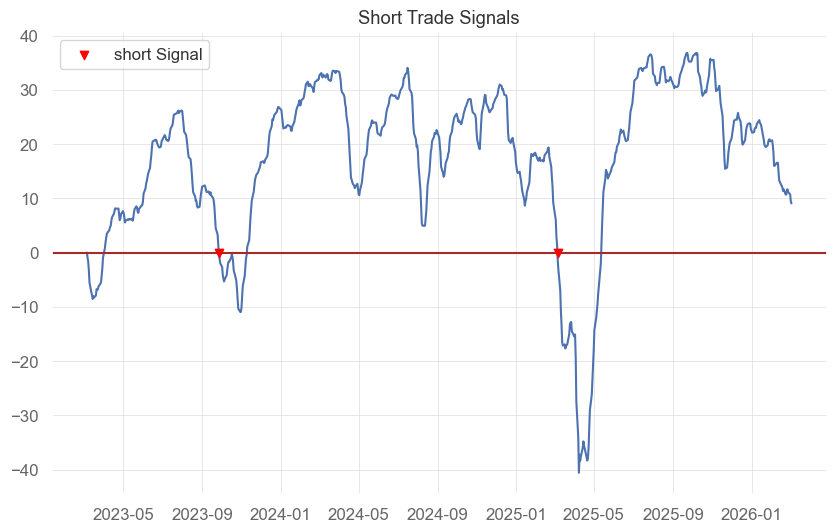

[Timestamp('2023-09-27 00:00:00-0400', tz='America/New_York'), Timestamp('2025-03-06 00:00:00-0500', tz='America/New_York')]
[Timestamp('2023-09-27 00:00:00-0400', tz='America/New_York'), Timestamp('2025-03-06 00:00:00-0500', tz='America/New_York')]


In [277]:
plt.plot(short_macd_line)
plt.title("Short Trade Signals")
plt.scatter(short_signals, [0] * len(short_signals), marker='v', color='red', label='short Signal', zorder=3)
plt.legend()
plt.axhline(0, color = "brown")
plt.show()
print(short_signals)
print(short_signals)


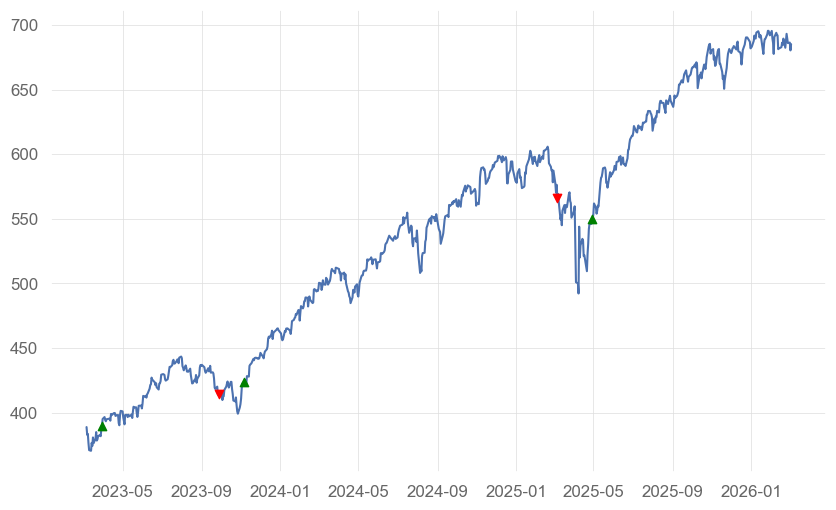

In [278]:
plt.plot(spy_closes)
plt.scatter(long_signals, spy_closes.loc[long_signals], marker='^', color='green', label='Long Signal', zorder=5)
plt.scatter(short_signals, spy_closes.loc[short_signals], marker='v', color='red', label='Long Signal', zorder=5)
plt.scatter(short_exit_signals, spy_closes.loc[short_exit_signals], marker='o', color='brown', label='Exit Signals', zorder=5)

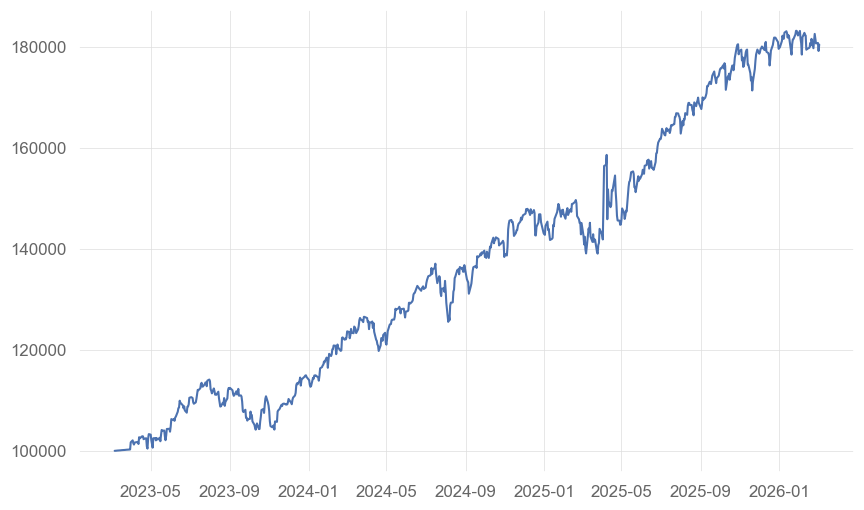

In [279]:
portfolio_time_series = [100000]
bankroll = 100000
shares = 0
short_contracts = 0
short_price = 0
rfr = 0.04 / 252
for i in range(1, len(spy_closes)):
    current_price = spy_closes.iloc[i]
    current_date = spy_closes.index[i]

    if current_date in long_signals:
        if short_contracts > 0:
            bankroll += (short_price - current_price) * short_contracts
            short_contracts = 0
            short_price = 0

        if bankroll > 0:
            shares = bankroll / current_price
            bankroll = 0

    elif current_date in short_signals:
        if shares > 0:
            bankroll += shares * current_price
            shares = 0
        short_price = current_price
        short_contracts = bankroll / current_price

    elif current_date in short_exit_signals:
        bankroll += shares * current_price + (short_price - current_price) * short_contracts
        shares = 0
        short_contracts = 0


    current_val = bankroll + (shares * current_price) + ((short_price - current_price) * short_contracts)
    bankroll *= (1 + rfr)

    portfolio_time_series.append(current_val)
portfolio_df = pd.DataFrame(data={'Portfolio_Value': portfolio_time_series}, index=spy_closes.index)
plt.plot(portfolio_df)
plt.show()


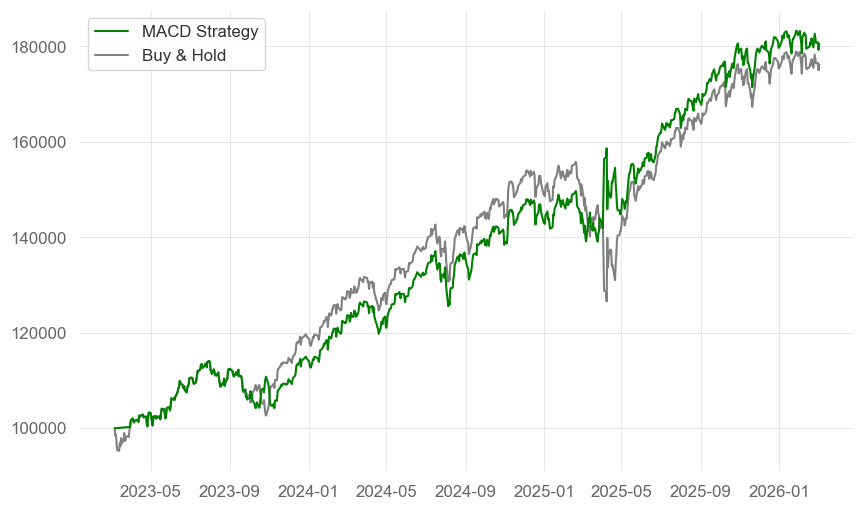

In [280]:
hold_long = [100000]
shares = 100000 / spy_closes.iloc[0]
for i in range(1, len(spy_closes)):
    portfolio_value = shares * spy_closes.iloc[i]
    hold_long.append(portfolio_value)
hold_df = pd.DataFrame(data={'Portfolio_Value': hold_long}, index=spy_closes.index)
comparison_df = pd.DataFrame(index=spy_closes.index)
comparison_df['MACD Strategy'] = portfolio_time_series
comparison_df['Buy & Hold SPY'] = hold_long
plt.plot(comparison_df['MACD Strategy'], label='MACD Strategy', color='green', zorder = 3)
plt.plot(comparison_df['Buy & Hold SPY'], label='Buy & Hold', color='gray')
plt.legend()
plt.show()



In [281]:
returns_macd = portfolio_df['Portfolio_Value'].pct_change()
returns_hold = hold_df['Portfolio_Value'].pct_change()
print(f'MACD Sharpe: {qs.stats.sharpe(returns_macd)}')
print(f'Hold Sharpe: {qs.stats.sharpe(returns_hold)}')


MACD Sharpe: 1.478913995438098
Hold Sharpe: 1.331551250680457
